## ⚡ 后台运行说明（大数据量请先看这里）

本 notebook 涉及 **超大数据量** 的 muon→DE / CEvNS 仿真，直接在前台逐格运行会非常耗时，且必须一直占用内核。

**推荐做法：先用后台脚本把重计算跑完并把结果落盘，再回到本 notebook 加载结果做分析/画图，无需重新加载海量数据。**

### 后台脚本位置
```
TPC_DE_SIm-test/scripts/run_20260730_background.py
```

### 如何在后台运行（三选一）

**Linux / macOS（推荐，适合服务器长时间跑）：**
```bash
cd TPC_DE_SIm-test
# 后台运行，日志写入 run.log，关闭终端也不中断
nohup python scripts/run_20260730_background.py --out-dir output/20260730 \
        --verbose > run.log 2>&1 &
# 查看进度
tail -f run.log
```

**Windows PowerShell（隐藏窗口，后台运行）：**
```powershell
cd "d:\大学资料\WORK\WORK\TPCwork\工具\Anacode\TPC_DE_SIm-test"
Start-Process python -ArgumentList 'scripts/run_20260730_background.py','--out-dir','output/20260730','--verbose' `
    -RedirectStandardOutput 'run.log' -RedirectStandardError 'run.err' -WindowStyle Hidden
```

**Windows 本会话后台任务（不隐藏，但终端可继续用）：**
```powershell
Start-Job -ScriptBlock {
    Set-Location "d:\大学资料\WORK\WORK\TPCwork\工具\Anacode\TPC_DE_SIm-test"
    & python scripts/run_20260730_background.py --out-dir output/20260730 --verbose
}
# 查看任务状态 / 结果
Get-Job
Receive-Job <作业ID>
```

### 生成的结果（全部写入 `TPC_DE_SIm-test/output/20260730/`）
| 文件 | 内容 |
|---|---|
| `de_result.npz` / `cevns_result.npz` | 规范化的 DE / CEvNS 原始结果（由 `pipe.save()` 生成） |
| `analysis_result.npz` | 合并后的分析数组：`de/cevns` 的 `st_cor`、`pattern`、`area`，`score_*`，`exposure_k`、`sel_thres` 等 |
| `summary.json` | 关键统计：`time_range_s`、各阶段事件数、最优 `k_area`、阈值、cut 后速率 |
| `*.png` | exposure、分类器 score、DE area 谱、st_cor vs pattern 图 |

### 回到本 notebook 加载结果（跳过所有重计算 cell）
运行下方「加载后台结果」cell 即可把 `analysis_result.npz` 里的数组注入当前内核，
后续的分析/画图 cell 直接使用这些变量即可。


In [ ]:
# ============================================================
# ✅ 加载后台运行结果（跑完 run_20260730_background.py 后运行本 cell）
# 运行后即可在当前内核使用 de_* / cevns_* / score_* / sel_thres 等变量，
# 无需重新加载海量数据。请按需修改 RESULT_DIR。
# ============================================================
import numpy as np
import json
from pathlib import Path

# 后台脚本输出目录（对应 --out-dir 参数）
RESULT_DIR = Path("TPC_DE_SIm-test/output/20260730")
if not RESULT_DIR.exists():
    # 若脚本放在项目根下运行，输出目录会是 ./output/20260730
    RESULT_DIR = Path("./output/20260730")
RESULT_DIR = RESULT_DIR.resolve()
print("加载结果目录:", RESULT_DIR)

if not RESULT_DIR.exists():
    raise FileNotFoundError(
        f"未找到后台结果目录 {RESULT_DIR}。\n"
        "请先运行 scripts/run_20260730_background.py 生成结果。"
    )

# ---- 加载分析数组（DE/CEvNS 合并后的 st_cor / pattern / area，以及 cut 结果）----
# 命名与原 notebook 后续绘图 cell 保持一致，加载后可直接复用，无需改后面的 cell。
d = np.load(RESULT_DIR / "analysis_result.npz")

# DE 侧（原 notebook 中变量名为 st_cor / pattern / DE_area）
st_cor        = d["de_st_cor"]
pattern       = d["de_pattern"]
DE_area       = d["de_area"]
# CEvNS 侧
cevns_st_cor  = d["cevns_st_cor"]
cevns_pattern = d["cevns_pattern"]
cevns_area    = d["cevns_area"]

k_area_list    = d["k_area_list"]
exposure_k     = d["exposure_k"]
best_k_area    = float(d["best_k_area"])
sel_thres      = float(d["sel_thres"])
sel_thres_thr  = float(d["sel_thres_thr"])
thresholds     = d["thresholds"]
left_DE_ratios = d["left_DE_ratios"]
right_cevns_ratios = d["right_cevns_ratios"]
score_DE       = d["score_DE"]
score_CEvNS    = d["score_CEvNS"]
DE_area_in_roi = d["DE_area_in_roi"]
DE_area_cut    = d["DE_area_cut"]
DE_cut         = d["DE_cut"]
total_time     = float(d["total_time"])
LXe_mass       = float(d["LXe_mass"])

print(f"DE   : n={len(DE_area)}  st_cor={len(st_cor)}  pattern={len(pattern)}")
print(f"CEvNS: n={len(cevns_area)}  st_cor={len(cevns_st_cor)}  pattern={len(cevns_pattern)}")
print(f"最优 k_area={best_k_area:.4f}, 分类器阈值 sel_thres={sel_thres:.4f}, 阈值法 sel_thres_thr={sel_thres_thr:.4f}")
print(f"DE cut 后事件数={len(DE_area_cut)}, time_range_s={total_time:.3f}")


# muon → DE 仿真（Pipeline，精细模板）
使用 DESimConfig + Pipeline，自动解析并打印关键路径，给出 muon 文件示例名与运行步骤。

In [128]:

import sys
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
import os

# 确保能 import 包（在仓库根运行时通常为 '.'）
sys.path.append('/home/leiyang/TPC_DE_SIm-test')
from relics_de_sim.config import DESimConfig
from relics_de_sim.pipeline import Pipeline
import relics_de_sim as rds
importlib.reload(rds)
print('relics_de_sim package imported')


relics_de_sim package imported


In [129]:
# 1) 加载并展示配置（使用仓内的 sim_config/Muon_sim.yaml）
cfg_rel = Path('../configs/muon_only.yaml')
if not cfg_rel.exists():
    raise FileNotFoundError(f'未找到配置文件: {cfg_rel.resolve()}')
cfg = DESimConfig.from_yaml(cfg_rel)
print('Loaded YAML source:', cfg.source_yaml)
print('Resolved paths:')
print(' muon_track_dir:', cfg.paths.muon_track_dir)
print(' lce_value:', cfg.paths.lce_value)
print(' position_reconstruction_model:', cfg.paths.position_reconstruction_model)
print('Simulation params: dead_time_s=', cfg.simulation.dead_time_s, ', muon_rate_hz=', cfg.simulation.muon_rate_hz)


Loaded YAML source: /home/leiyang/TPC_DE_SIm-test/configs/muon_only.yaml
Resolved paths:
 muon_track_dir: /home/leiyang/TPC_DE_SIm-test/muon_track
 lce_value: /home/leiyang/TPC_DE_SIm-test/LCE_info/LCE_value.npy
 position_reconstruction_model: /home/leiyang/TPC_DE_SIm-test/models/CnnRelics.ckpt
Simulation params: dead_time_s= 0.002 , muon_rate_hz= 6.2


In [130]:
cfg.simulation.muon_rate_hz = 4

In [131]:

# 统一按新目录结构查找 muon/gamma 事件文件
from pathlib import Path

def collect_event_files(base_dir, event_type):
    base = Path(base_dir)
    event_dir = base / f"{event_type}_events"
    matches = sorted(event_dir.glob(f"{event_type}_events.*.npy")) if event_dir.exists() else []
    if not matches:
        matches = sorted(base.rglob(f"{event_type}_events.*.npy"))
    if not matches:
        matches = sorted(base.rglob("*.npy"))
    return matches

muon_root = Path("/home/leiyang/TPC_DE_SIm-test/muon_track")
cfg.paths.muon_track_dir = str(muon_root)

muon_files = collect_event_files(muon_root, "muon")
gamma_files = collect_event_files(muon_root, "gamma")

print("muon_events files:", len(muon_files))
for p in muon_files[:1]:
    print(" ", p)

print("gamma_events files:", len(gamma_files))
for p in gamma_files[:0]:
    print(" ", p)

# 2) 载入 muon/gamma 文件：合并两类文件
all_input_files = [str(p) for p in (muon_files[:1] + gamma_files[:0])]
print("total files to load:", len(all_input_files))
for p in all_input_files:
    print(" ", p)

# 3) 构造 Pipeline 并按阶段运行（同时加载 muon_events 和 gamma_events）
pipe = Pipeline(cfg)
print("Pipeline created. device=", pipe.device)

if all_input_files:
    try:
        pipe.load_muon_tracks(all_input_files)   # 先测试前8个文件
        print("Loaded muons: merged shape =", None if pipe.merged_muon is None else pipe.merged_muon.shape)
        print("dense muon shape =", None if pipe.dense_muon is None else pipe.dense_muon.shape)
    except Exception as e:
        print("load_muon_tracks 失败：", e)
else:
    print("没有找到 muon/gamma 文件，跳过 load_muon_tracks。")



muon_events files: 11
  /home/leiyang/TPC_DE_SIm-test/muon_track/muon_events/muon_events.0.npy
gamma_events files: 6
total files to load: 1
  /home/leiyang/TPC_DE_SIm-test/muon_track/muon_events/muon_events.0.npy
Pipeline created. device= auto


Reading muon files: 100%|██████████| 1/1 [00:00<00:00, 29.71it/s]


Loaded muons: merged shape = (745268,)
dense muon shape = (4117800,)


In [132]:
# 4) 生成延迟电子、模拟 pattern、位置重建与评分（有条件执行）
if pipe.dense_muon is None:
    print('未生成 dense_muon —— 请先运行上一步')
else:
    print('simulate_delayed_electrons() ...')
    pipe.simulate_delayed_electrons()
    print('simulate_pile_up_patterns() ...')
    pipe.simulate_pile_up_patterns()
    print('recon_position_de() ...')
    try:
        pipe.recon_position_de()
    except Exception as e:
        print('位置重建失败（可能缺少模型或 PyTorch），错误：', e)
    print('score() ...')
    try:
        pipe.score()
    except Exception as e:
        print('评分失败：', e)
    # 概览每个 pile-up multiplicity 的 kept 事件数
    for order, res in zip(pipe.pile_up_orders, pipe.pile_up_results):
        print(f'order={order} kept={len(res.pe_by_area)}')


simulate_delayed_electrons() ...
simulate_pile_up_patterns() ...
recon_position_de() ...
Using device: cuda
model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 2091614/2091614 [00:03<00:00, 613449.57it/s]


total samples:  2091614 , using a 512 batch for data loader


100%|██████████| 4086/4086 [00:18<00:00, 223.25it/s]


Using device: cuda
model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


...

total samples:  7166 , using a 512 batch for data loader


100%|██████████| 14/14 [00:00<00:00, 159.15it/s]


score() ...


space-time correlation: 100%|██████████| 1/1 [00:00<00:00,  1.63it/s]

order=2 kept=2091614
order=3 kept=404908
order=4 kept=112984
order=5 kept=39539
order=6 kept=16674
order=7 kept=7166


In [155]:
len(pipe.pile_up_results)

6

In [ ]:
pipe.pile_up_results[i].

array([[ 2.61719951,  2.718982  ,  1.09019133, ...,  0.73294702,
         0.        ,  1.39903201],
       [ 1.8264399 ,  0.        ,  6.65636065, ...,  3.67234651,
         1.88134852,  4.41800086],
       [ 0.81022499,  2.13813802,  1.76933032, ...,  0.94251533,
         0.        ,  1.85916319],
       ...,
       [ 2.8064357 ,  3.13133383,  0.        , ...,  3.941127  ,
         0.        ,  1.00955504],
       [ 9.08126978,  8.08317946, 11.59787381, ...,  3.9766945 ,
         3.9873843 ,  4.14365366],
       [25.18757747, 12.71589572,  0.18732688, ...,  8.43703696,
         4.81627295,  2.19615071]])

In [158]:
event_rate = np.array([len(pipe.pile_up_pattern_coef[i]) for i in range(len(pipe.pile_up_results))]) / pipe.time_range_s

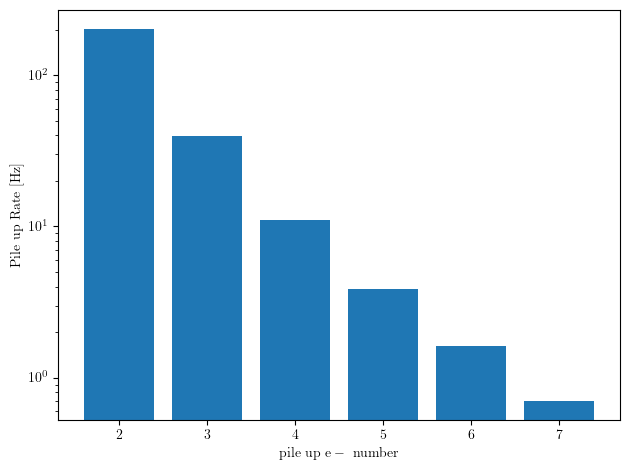

In [159]:
fig = plt.figure()

plt.yscale('log')
plt.bar(pipe.pile_up_orders,event_rate)
# plt.ylim(0,800)
# plt.xlim(1,6)
plt.ylabel(r'$\mathrm{Pile\ up\ Rate\ [Hz]}$')
plt.xlabel(r'$\mathrm{pile\ up\ e-\ number}$')
plt.tight_layout()
plt.savefig("Pile_up_Rate.png")
plt.show()

In [133]:
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

def pattern_plot(phe_pmt, electron = [] , pos_recons = [], pmt_info = pipe.pmt_top,title = "",savefig = False):
    artists = list()
    cmap = mpl.cm.viridis
    # 定义灰度色图
    # cmap = cm.get_cmap("viridis")
    # norm = mpl.colors.LogNorm(vmin=1, vmax=phe_pmt.max(), clip=True)
    # 修改1：添加有效性检查
    phe_pmt = np.asarray(phe_pmt)
    phe_pmt = np.nan_to_num(phe_pmt, nan=0.0)
    
    # 修改2：安全设置 norm
    max_val = phe_pmt.max()
    if max_val <= 1:
        # 如果最大值 <= 1，使用线性归一化
        norm = mpl.colors.Normalize(vmin=0, vmax=max(1, max_val))
    else:
        try:
            norm = mpl.colors.LogNorm(vmin=1, vmax=max_val, clip=True)
        except ValueError:
            norm = mpl.colors.Normalize(vmin=0, vmax=max_val)
    colors = ['blue', 'green', 'yellow','red']  # 自定义颜色列表
    #norm = mpl.colors.LogNorm(vmin=1, vmax=1000, clip=True)
    fig = plt.figure(figsize=(7, 6))

    # grid = ImageGrid(fig, 111, (1,1), cbar_mode='single', axes_pad=0.1, cbar_pad=0.2)
    grid = ImageGrid(fig, 111, (1,1))

    # PMT plot
    # for pmt_id in range(64):
    #     pmt = pmt_info[pmt_id]
    #     pe_value = phe_pmt[pmt_id]
    #     # print(str(round(pe_value,2)))
    #     # grid[0].text(pmt['x'], pmt['y'], str(pmt['ChannelID']), ha='center', va='center')
    #     grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
    #     # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc=cmap(norm(phe_pmt[pmt_id])),alpha = 0.86))
    #     # grid[0].add_patch(artists[pmt['ChannelID']])
    for pmt_id in range(28):
        pmt = pmt_info[pmt_id]
        pe_value = phe_pmt[pmt_id]
        # 检查 PMT 值并设定颜色
        if phe_pmt[pmt_id] < 0.1:
            pmt_color = 'white'  # 小于0.1的通道颜色为白色
        else:
            pmt_color = cmap(norm(phe_pmt[pmt_id]))
            # 绘制alpha为1的白色边框
        grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
        border = Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc='none', ec='black', lw=1, alpha=1)    
        grid[0].add_patch(border)

        # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
        #                angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
        #                alpha=(phe_pmt[i][pmt_id] / vmax)**0))

        artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
                       angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
                       alpha=1))
        grid[0].add_patch(artists[pmt['ChannelID']])
    # event plot
    if len(electron)>0:
        grid[0].plot(electron['xd']/10, electron['yd']/10, 'ro', markersize=12 ,label = 'Position')
  
    # recon_pos plot
    if len(pos_recons)>0:
        grid[0].plot(pos_recons[0]/10, pos_recons[0]/10, 'b*', markersize=12, label = 'Recon Position')
        
    # muon_point_plot
    # if muon_id_list is not None:
        # for i, muon_id in enumerate(muon_id_list):
            # color = colors[i % len(colors)]  # 从颜色列表中选择颜色
            # grid[0].plot(dense_muon_points[dense_muon_points['eventId'] == muon_id]['xd']/10, dense_muon_points[dense_muon_points['eventId'] == muon_id]['yd']/10, 'o', label="muon id: {}".format(muon_id), markersize=2, alpha=0.5, color=color)
            
    # TPC outline
    # angle = np.arange(13)*np.pi/6
    # outer_r = 14/np.cos(np.pi/12)
    # grid[0].plot(outer_r*np.cos(angle), outer_r*np.sin(angle), c='k', lw=3)

    # Colorbar
    # grid.cbar_axes[0].colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm))

    # Other settings
    grid[0].axis('equal')
    grid[0].set_xlabel('x/cm')
    grid[0].set_ylabel('y/cm')
    grid[0].legend()
    # grid[0].legend(bbox_to_anchor=(1.2, 0), loc=3, borderaxespad=0, prop={'size': 7})
    grid[0].set_title(title)
    if savefig == True: 
        plt.savefig(title+".png")
    plt.legend()
    plt.show()
    return 0

In [134]:
pipe.delayed_electron

array([(    0,   1.25718827,  8.96375658, 1.71884915e-01, 1.73890960e-01),
       (    0,   3.27666077,  7.52160648, 1.71884915e-01, 1.73893642e-01),
       (    0,  14.38375954, -0.41021911, 1.71884915e-01, 1.73895418e-01),
       ...,
       (41174, -58.34842954, 20.42508972, 1.02937722e+04, 1.02957384e+04),
       (41174, -35.16182233, 19.28716532, 1.02937722e+04, 1.02957539e+04),
       (41174,  -3.54372159, 17.73545024, 1.02937722e+04, 1.02957659e+04)],
      dtype=[('eventId', '<i4'), ('xd', '<f8'), ('yd', '<f8'), ('muon_time', '<f8'), ('e_time', '<f8')])

In [135]:
pipe.pile_up_results[3].pe_info

array([(    0, 0.8972208 ,  0, 1.04045665e+00, 0),
       (    0, 0.79071285,  0, 1.04045665e+00, 0),
       (    0, 1.19391551,  1, 1.04045665e+00, 0), ...,
       (39538, 1.01212895, 55, 1.02937746e+04, 0),
       (39538, 0.89889453, 55, 1.02937746e+04, 0),
       (39538, 1.27150836, 55, 1.02937746e+04, 0)],
      dtype=[('event_id', '<u8'), ('area', '<f8'), ('channel', '<u2'), ('e_time', '<f8'), ('e_id', '<u4')])

In [136]:
pipe.pile_up_indices[2][0]

array([103, 104, 105, 106])

In [137]:
len(pipe.pile_up_results[0].light_pattern[0])

56

In [138]:
pipe.pile_up_indices[0][0]

array([2, 3])

In [139]:
pipe.delayed_electron['eventId']

array([    0,     0,     0, ..., 41174, 41174, 41174], dtype=int32)

/tmp/ipykernel_1363030/79588600.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


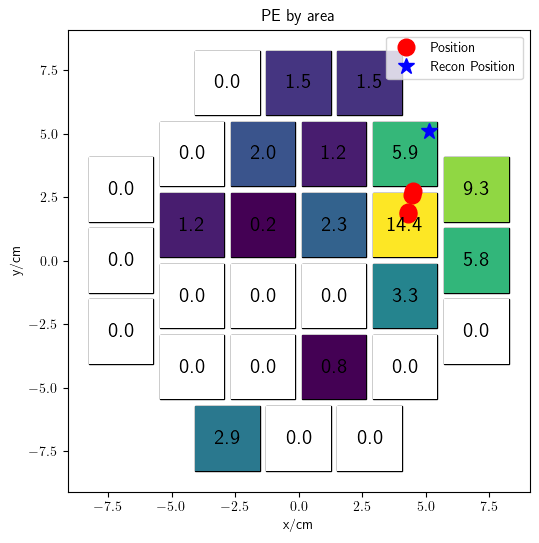

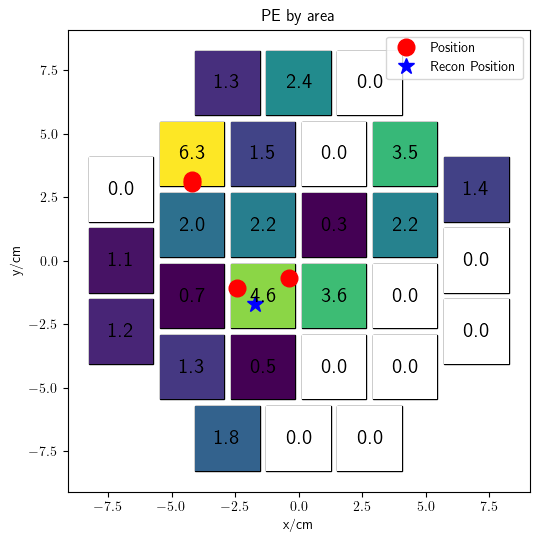

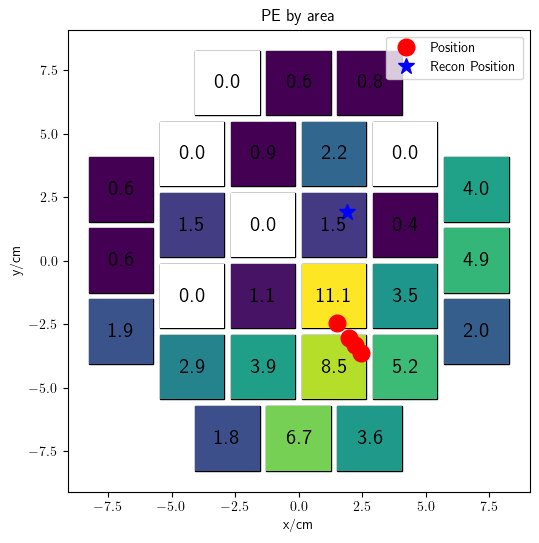

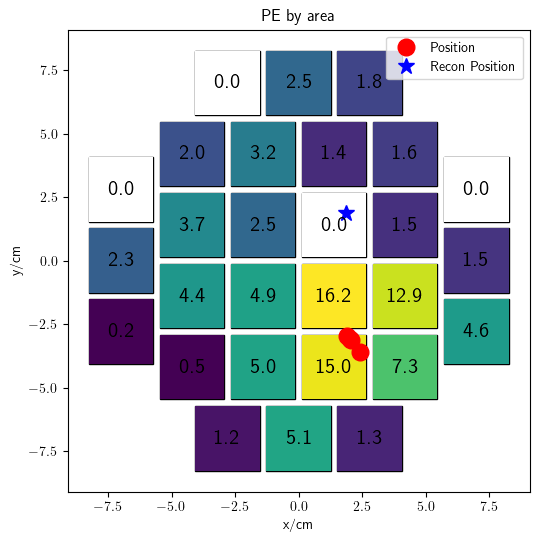

/tmp/ipykernel_1363030/79588600.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


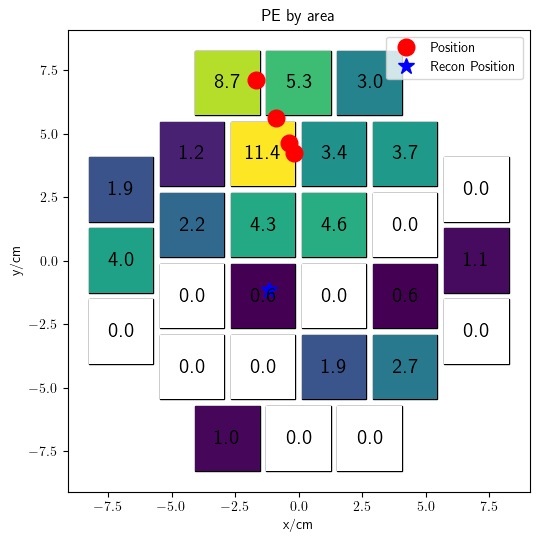

In [140]:
e_num = 4
# mask = np.ptp(pipe.pile_up_events[e_num-2]['eventId'], axis=1) != 0 
mask = pipe.pile_up_pattern_coef[e_num-2] < -200
np.sum(mask)
valid_indices = np.where(mask)[0]

for i in range(min(5, len(valid_indices))):
    idx = valid_indices[i]
# pattern_plot(pipe.pile_up_results[e_num-2].light_pattern[i], electron=[], pos_recons = pipe.pile_up_pos_recon[e_num-2][i], pmt_info = pipe.pmt_top,title = "Pile up light pattern")
    pattern_plot(pipe.pile_up_results[e_num-2].pe_by_area[idx], electron=pipe.pile_up_events[e_num-2][idx], pos_recons = pipe.pile_up_pos_recon[e_num-2][idx], pmt_info = pipe.pmt_top,title = "PE by area")

In [141]:
pattern = np.concatenate(pipe.pile_up_pattern_coef)
st_cor = np.concatenate(pipe.pile_up_st_cor)

In [142]:
len(pattern)

2672885

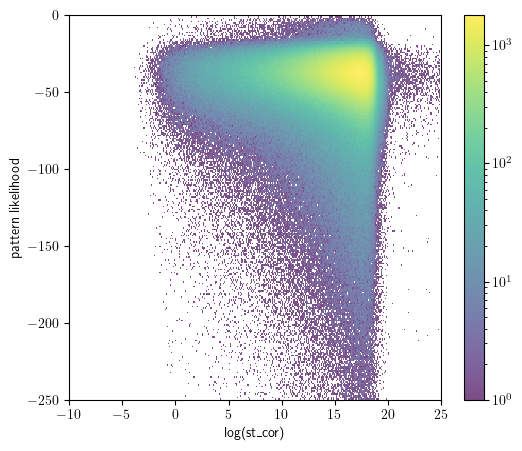

In [143]:
from matplotlib.colors import LogNorm

x_bins = np.arange(-10,25,0.1)
y_bins = np.arange(-250,0,1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(st_cor), pattern, bins = (x_bins, y_bins), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('log(st_cor)'); ax.set_ylabel('pattern likelihood')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10,25)
plt.ylim(-250,0)
plt.show()

In [144]:
from relics_de_sim import DESimConfig, Pipeline
cfg = DESimConfig.from_yaml('../configs/cevns_sim.yaml')
print('cevns_e_spectrum:', cfg.paths.cevns_e_spectrum)

cevns_e_spectrum: /home/leiyang/TPC_DE_SIm-test/data/cevns_sim_20_3e.npz


In [145]:
# from pathlib import Path
# muon_files = [Path(cfg.paths.muon_track_dir) / f'muon_track.{i}.npy' for i in range(4)]
# pipe_cevns = Pipeline(cfg, rng=np.random.default_rng(7))
# pipe_cevns.load_muon_tracks(muon_files)
# print(f'time range: {pipe_cevns.time_range_s:.1f} s')

In [146]:

muon_paths = [str(p) for p in muon_files[:1]]
gamma_paths = [str(p) for p in gamma_files[:0]]
load_files = muon_paths + gamma_paths

pipe_cevns = Pipeline(cfg, rng=np.random.default_rng(7))
pipe_cevns.load_muon_tracks(load_files)
print("loaded file count:", len(load_files))
print(load_files)

Reading muon files:   0%|          | 0/1 [00:00<?, ?it/s]

Reading muon files: 100%|██████████| 1/1 [00:00<00:00, 29.37it/s]


loaded file count: 1
['/home/leiyang/TPC_DE_SIm-test/muon_track/muon_events/muon_events.0.npy']


In [147]:
pipe.time_range_s

10294.5

In [160]:
try:
    pipe_cevns.simulate_cevns()
    for arr in pipe_cevns.cevns_points:
        if len(arr):
            print(f'n_e={int(arr["num_e"][0])}: {len(arr)} events')
except ImportError as exc:
    print('CNN inference unavailable:', exc)

Using device: cuda
model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 1/1 [00:00<00:00, 21076.90it/s]


total samples:  1 , using a 512 batch for data loader


100%|██████████| 1/1 [00:00<00:00, 47.68it/s]

Using device: cuda


...

model loaded from epoch ../models/DeepResNet25.ckpt ,using device: cuda 


100%|██████████| 481/481 [00:00<00:00, 521038.28it/s]


total samples:  481 , using a 512 batch for data loader


space-time correlation: 100%|██████████| 1/1 [00:00<00:00, 26.07it/s]

n_e=1: 1 events
n_e=3: 357357 events
n_e=4: 158811 events
n_e=5: 71487 events
n_e=6: 28554 events
n_e=7: 10298 events
n_e=8: 3685 events
n_e=9: 1329 events
n_e=10: 481 events


In [161]:
arr = np.concatenate(pipe_cevns.cevns_points)

In [162]:
from relics_de_sim.cuts import (
    PatternSTCut,
    fit_pattern_st_cut,
    pattern_likelihood,
)

cevns_st_cor = arr['st_cor']
cevns_pattern = pattern_likelihood(arr['pe_by_area'], arr['recons_light_pattern'], n_top=28)

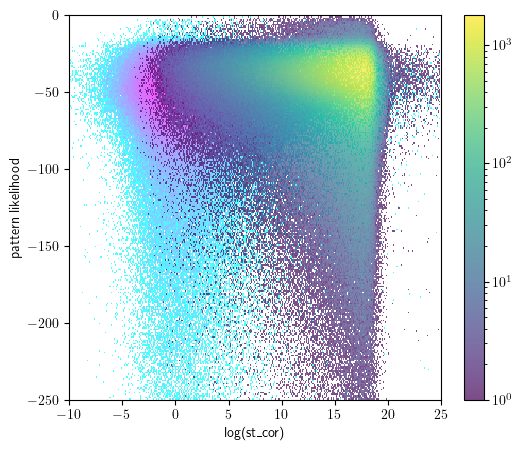

In [163]:
x_bins = np.arange(-10,25,0.1)
y_bins = np.arange(-250,0,1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(cevns_st_cor), cevns_pattern, bins = (x_bins, y_bins), cmap='cool', norm=LogNorm(),alpha = 0.7)
h = ax.hist2d(np.log(st_cor), pattern, bins = (x_bins, y_bins), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('log(st_cor)'); ax.set_ylabel('pattern likelihood')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10,25)
plt.ylim(-250,0)
plt.show()

In [164]:
cevns_area = np.sum(arr['pe_by_area'],axis=1)
cevns_area

array([ 31.44003526,  87.48320072,  84.99348435, ...,  40.12757506,
       129.21794001, 170.69850848])

In [165]:
len(pipe.pile_up_results)

6

In [204]:
area_e = np.sum(pipe.pile_up_results[1].pe_by_area,axis=1)

In [205]:
np.mean(area_e)

99.4435500034485

In [168]:
DE_pe_by_area = []
for i in range(len(pipe.pile_up_results)):
    DE_pe_by_area.append(pipe.pile_up_results[i].pe_by_area)

In [169]:
DE_pe_by_area = np.concatenate(DE_pe_by_area)

In [170]:
DE_area = np.sum(DE_pe_by_area,axis=1)
DE_area

array([100.55783906,  96.20057547,  50.15614381, ..., 237.72958112,
       227.76109353, 174.9659492 ])

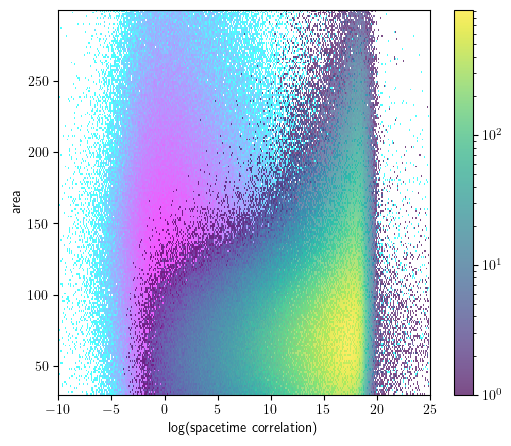

In [171]:
x_bins = np.arange(-10,25,0.1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(cevns_st_cor), cevns_area, bins = (x_bins, 200), cmap='cool', norm=LogNorm(),alpha = 0.7)
h = ax.hist2d(np.log(st_cor), DE_area, bins = (x_bins, 200), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('log(spacetime correlation)'); ax.set_ylabel('area')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10,25)

plt.show()

In [172]:
arr.dtype

dtype([('cevnsID', '<i4'), ('pos_original', [('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8')]), ('t', '<f8'), ('num_e', '<f8'), ('light_pattern', '<f8', (56,)), ('pe_pattern', '<u2', (56,)), ('area_pattern', '<f8', (56,)), ('pe_by_area', '<f8', (56,)), ('pos_recon', [('xd', '<f8'), ('yd', '<f8')]), ('recons_light_pattern', '<f8', (56,)), ('st_cor', '<f8')])

In [173]:
cevns_pe_by_area = arr['pe_by_area']
cevns_pe_by_area.shape

(632003, 56)

/tmp/ipykernel_1363030/79588600.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


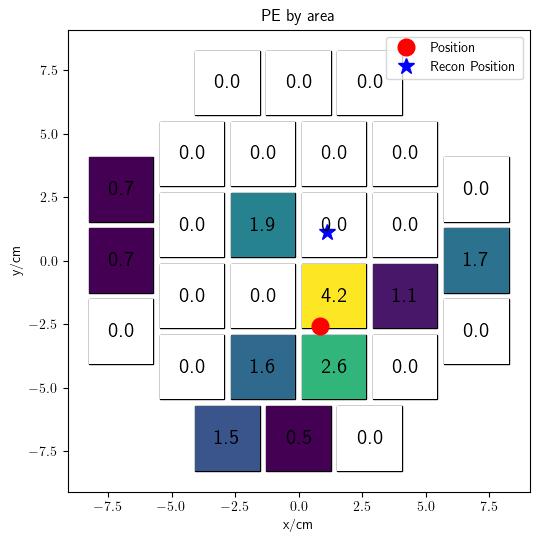

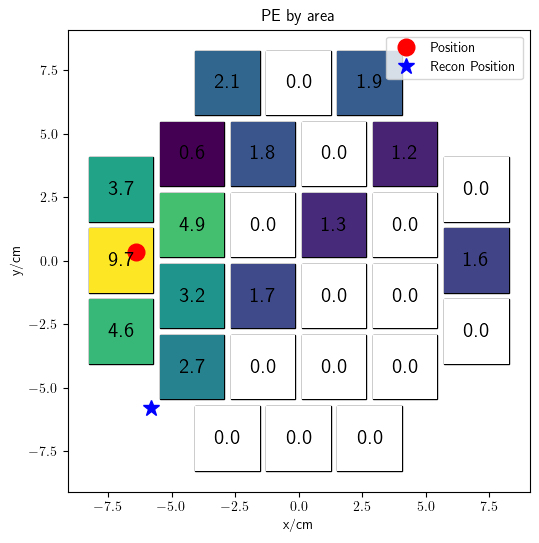

/tmp/ipykernel_1363030/79588600.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


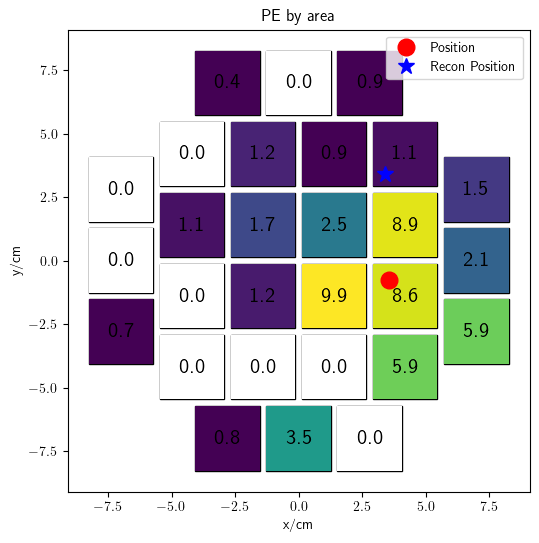

/tmp/ipykernel_1363030/79588600.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


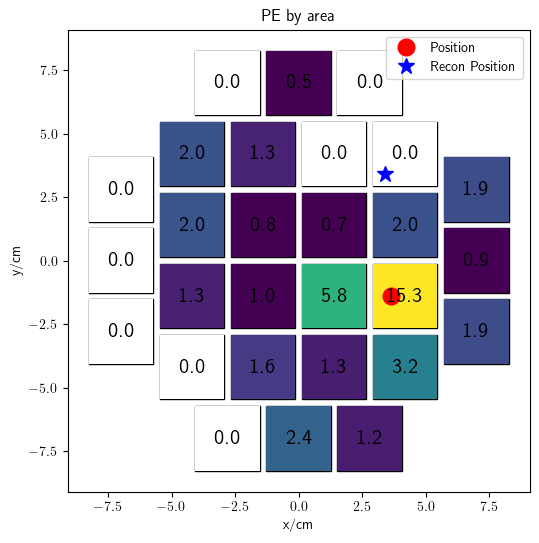

/tmp/ipykernel_1363030/79588600.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


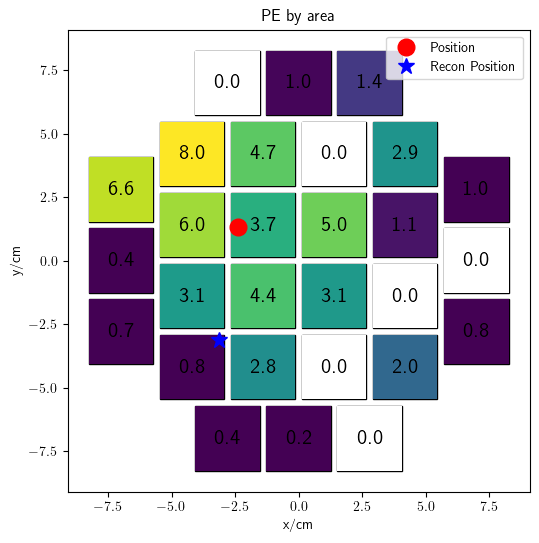

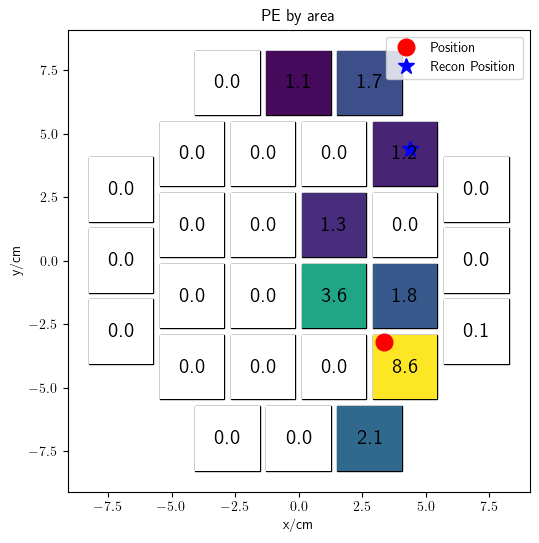

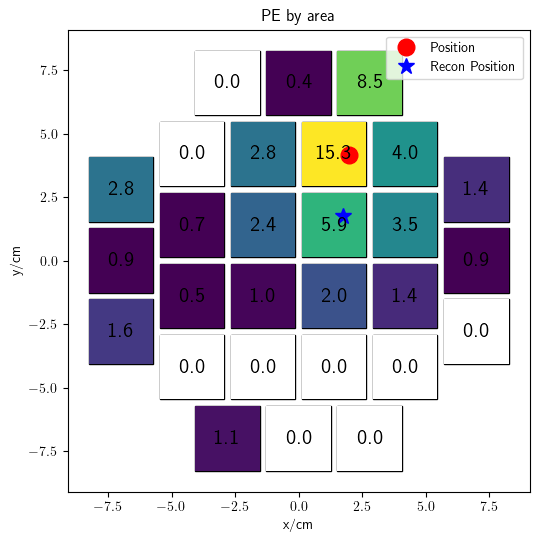

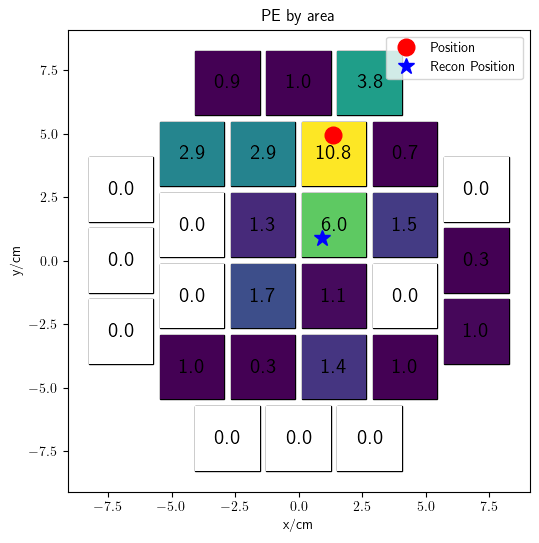

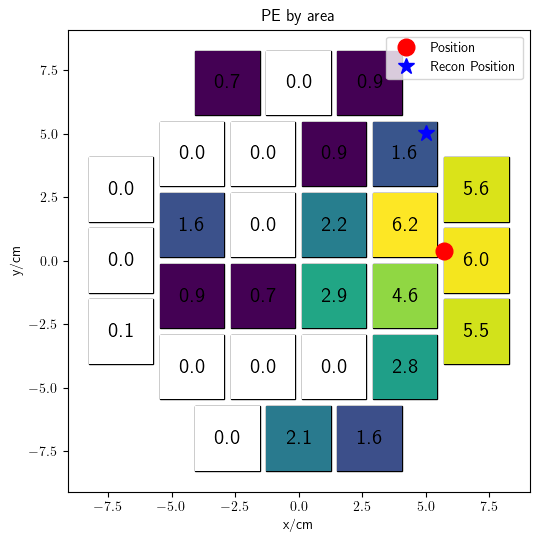

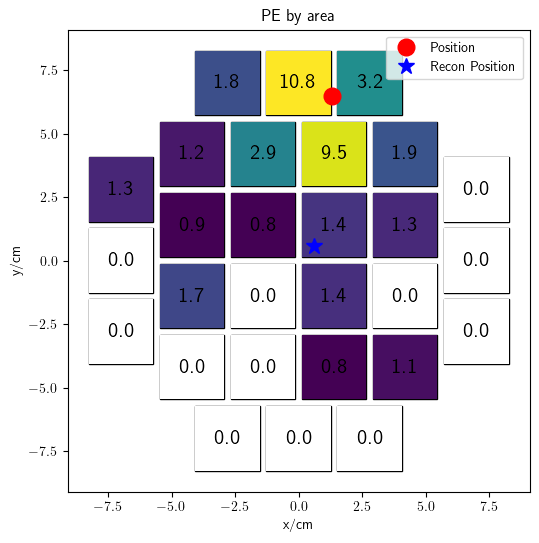

In [174]:
mask = cevns_pattern > -50

valid_indices = np.where(mask)[0]


for i in range(10):
    idx = valid_indices[i]
    # pattern_plot(pipe.pile_up_results[e_num-2].light_pattern[i], electron=[], pos_recons = pipe.pile_up_pos_recon[e_num-2][i], pmt_info = pipe.pmt_top,title = "Pile up light pattern")
    pattern_plot(cevns_pe_by_area[idx], electron=arr['pos_original'][idx], pos_recons = arr['pos_recon'][idx], pmt_info = pipe.pmt_top,title = "PE by area")

In [175]:
from tqdm import tqdm

def position_variance(pe_by_area, pmt_info = pipe.pmt_top, n_top=28):

    # 计算每个事件的加权平均位置
    weights = pe_by_area / np.sum(pe_by_area, axis=1, keepdims=True)
    weights_top = weights[:, :n_top]

    pmts = np.array(pmt_info[:n_top])
    
    pos_variance = []
    for item in tqdm(weights_top):
        x_virance = np.std(item*pmts['x'])
        y_virance = np.std(item*pmts['y'])

        pos_variance.append(x_virance**2+y_virance**2)
    return pos_variance

In [176]:
# cevns_pos_virance = position_variance(cevns_pe_by_area)
# DE_pos_virance = position_variance(DE_pe_by_area)

In [177]:
# x_bins = np.arange(-10,25,0.1)

# fig, ax = plt.subplots(figsize=(6, 5))
# h = ax.hist2d(np.log(cevns_st_cor), cevns_pos_virance, bins = (x_bins, 200), cmap='cool', norm=LogNorm(),alpha = 0.7)
# h = ax.hist2d(np.log(st_cor), DE_pos_virance, bins = (x_bins, 200), cmap='viridis', norm=LogNorm(),alpha = 0.7)
# ax.set_xlabel('log(spacetime correlation)'); ax.set_ylabel('PMT array variance')
# plt.colorbar(h[3], ax=ax)
# plt.xlim(-10,25)

# plt.show()

In [178]:
# y_bins = np.arange(-250,0,1)

# fig, ax = plt.subplots(figsize=(6, 5))
# h = ax.hist2d(cevns_area, cevns_pos_virance, bins = (200,200), cmap='cool', norm=LogNorm(),alpha = 0.7)
# h = ax.hist2d(DE_area, DE_pos_virance, bins = (200,200), cmap='viridis', norm=LogNorm(),alpha = 0.7)
# ax.set_xlabel('signal size[PE]'); ax.set_ylabel('PMT array variance')
# plt.colorbar(h[3], ax=ax)
# plt.xlim(90,300)
# # plt.ylim(-250,0)
# plt.show()

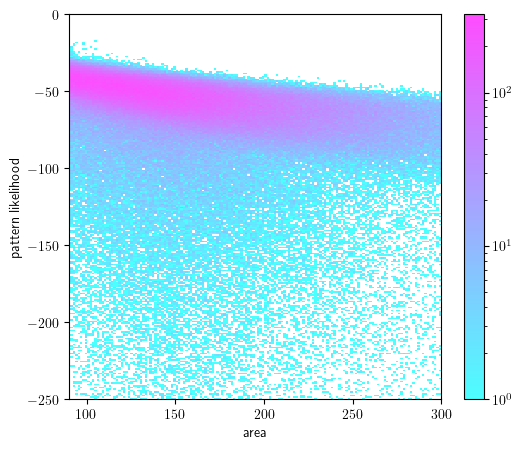

In [179]:
y_bins = np.arange(-250,0,1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(cevns_area, cevns_pattern, bins = (200, y_bins), cmap='cool', norm=LogNorm(),alpha = 0.7)
# h = ax.hist2d(DE_area, pattern, bins = (200, y_bins), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('area'); ax.set_ylabel('pattern likelihood')
plt.colorbar(h[3], ax=ax)
plt.xlim(90,300)
plt.ylim(-250,0)
plt.show()

In [180]:
def calculate_score(st_cor, area, k_area):
    return  k_area * area - np.log(st_cor)

In [181]:
cevns_ROI_mask = (cevns_area>120) & (cevns_area<300)
DE_ROI_mask = (DE_area>120) & (DE_area<300)

In [182]:
from tqdm import tqdm

exposure = []

k_area_list = np.arange(-0.1,0.4,0.005)
k_list = []
exposure_k = []
for k in tqdm(k_area_list):
    score_cevns = calculate_score(cevns_st_cor[cevns_ROI_mask], cevns_area[cevns_ROI_mask], k_area = k)
    score_DE = calculate_score(st_cor[DE_ROI_mask], DE_area[DE_ROI_mask], k_area = k)
    valid_score_cevns = score_cevns[~np.isnan(score_cevns)]
    valid_score_DE = score_DE[~np.isnan(score_DE)]   
    x = np.percentile(valid_score_DE, 100-0.001)
    exposure_k.append(len(valid_score_cevns[valid_score_cevns>x])/len(valid_score_cevns))
    k_list.append([k,x])
    exposure.append(exposure_k)
exposure = np.array(exposure)

100%|██████████| 100/100 [00:02<00:00, 36.09it/s]


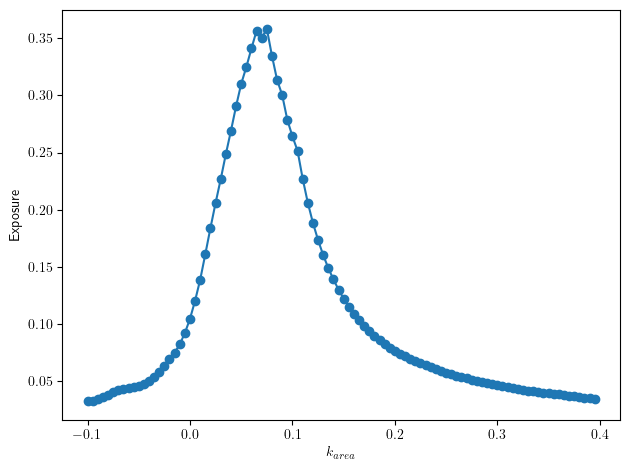

In [183]:
plt.figure()

plt.plot(k_area_list, exposure_k, marker='o')
plt.xlabel(r"$k_{area}$")
plt.ylabel("Exposure")
plt.tight_layout()

plt.show()

In [184]:
index_of_max = np.argmax(exposure)
print(k_list[index_of_max],np.max(exposure))
k_area, b = k_list[index_of_max]
b = -b

[0.07500000000000015, 12.944295645640262] 0.35836033710333043


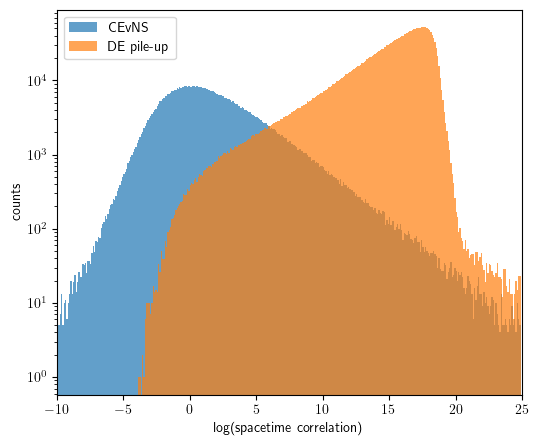

In [185]:
x_bins = np.arange(-10,25,0.1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist(np.log(cevns_st_cor), bins = x_bins, alpha = 0.7, label = 'CEvNS')
h = ax.hist(np.log(st_cor), bins = x_bins, alpha = 0.7, label = 'DE pile-up')
ax.set_xlabel('log(spacetime correlation)'); ax.set_ylabel('counts')

plt.xlim(-10,25)
plt.yscale('log')
plt.legend()
plt.show()

In [186]:
# thresholds = np.arange(-25, 10, 0.1)  # 你可以调整这个范围和步长以适应你的数据

# # 初始化两个比例的列表
# left_DE_ratios = []
# right_cevns_ratios = []

# # 计算每个阈值下的比例
# for threshold in thresholds:
#     left_DE_ratio = np.sum(-np.log(st_cor) < threshold) / len(np.log(st_cor))
#     right_cevns_ratio = np.sum(-np.log(cevns_st_cor) > threshold) / len(np.log(cevns_st_cor))
    
#     left_DE_ratios.append(left_DE_ratio)
#     right_cevns_ratios.append(right_cevns_ratio)


# left_DE_ratios = np.array(left_DE_ratios)

# if np.any(left_DE_ratios > 1-0.0001):
#     index = np.argmax(left_DE_ratios > 1-0.0001)
# else:
#     index = -1  # 或者 None，表示未找到

# print(index)

# # 导入所需要的库
# import matplotlib.pyplot as plt
# import numpy as np

# cevns_color = '#5882F8'
# DE_color = '#F9885E'

# # 创建一个新的图形并设置大小
# fig, ax1 = plt.subplots(figsize=(8,6))
# plt.rcParams['text.usetex'] = True

# # 开始处理第一个图，使用左侧y轴

# color = 'tab:blue'
# bins = np.arange(-25, 10, 0.1)

# ax1.hist(-np.log(st_cor), bins=bins, log=True, label='Pile-up DE', alpha=0.7, color=DE_color,density = True)  # 添加 alpha 参数
# ax1.hist(-np.log(cevns_st_cor), bins=bins, log=True, label=r"CE$\nu$NS", alpha=0.7, color=cevns_color,density = True)  # 添加 alpha 参数
# ax1.set_ylabel(r'$\mathrm{Frequency}$')  # 右侧y轴标签
# ax1.set_xlabel(r'$\mathrm{-log(spacetime\ correlation)}$')  # x轴标签
# ax1.tick_params(axis='y')  # y轴标签颜色

# # 第二个图，使用右侧y轴
# ax2 = ax1.twinx() 
# ax2.set_ylabel(r'$\mathrm{Signal\ Acceptance\ or\ Rejecting\ Power}$')  # 左侧y轴标签
# ax2.plot(thresholds, left_DE_ratios, label='Pile-up Cut Rate', color= DE_color)  # 绘制左侧 DE 的比例曲线
# ax2.plot(thresholds, right_cevns_ratios, label=r'CE$\nu$NS Survival Rate', color=cevns_color)  # 绘制右侧 CEVNS 的比例曲线
# # ax2.grid(True)
# ax2.tick_params(axis='y')  # y轴标签颜色


# # 获得所有子图的 legend labels 和 handles
# lines, labels = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()

# # 创建一个全局的legend
# fig.legend(lines + lines2, labels + labels2, loc=(0.10,0.80))
# # fig.legend(lines, labels, loc=(0.17,0.8))

# # fig.tight_layout(pad = 5)  # 使布局紧密
# # plt.title('Pattern Classifier', fontsize=16)  # 图表标题

# plt.axvline(x=thresholds[index], color='red', linestyle='dashed')
# plt.tight_layout() 
# # plt.savefig("classifier_score.png")
# plt.show()  # 显示绘图


In [187]:
score_DE = calculate_score(st_cor[DE_ROI_mask], DE_area[DE_ROI_mask], k_area)
score_CEvNS = calculate_score(cevns_st_cor[cevns_ROI_mask], cevns_area[cevns_ROI_mask], k_area)
score_CEvNS = score_CEvNS[~np.isnan(score_CEvNS)]
score_DE = score_DE[~np.isnan(score_DE)]

In [188]:
thresholds = np.arange(-25, 50, 0.2)  # 你可以调整这个范围和步长以适应你的数据

# 初始化两个比例的列表
left_DE_ratios = []
right_cevns_ratios = []

# 计算每个阈值下的比例
for threshold in thresholds:
    left_DE_ratio = np.sum(score_DE < threshold) / len(score_DE)
    right_cevns_ratio = np.sum(score_CEvNS > threshold) / len(score_CEvNS)
    
    left_DE_ratios.append(left_DE_ratio)
    right_cevns_ratios.append(right_cevns_ratio)

In [223]:
left_DE_ratios = np.array(left_DE_ratios)

if np.any(left_DE_ratios > 1-0.00001):
    index = np.argmax(left_DE_ratios > 1-0.00001)
else:
    index = -1  # 或者 None，表示未找到

print(index)

190


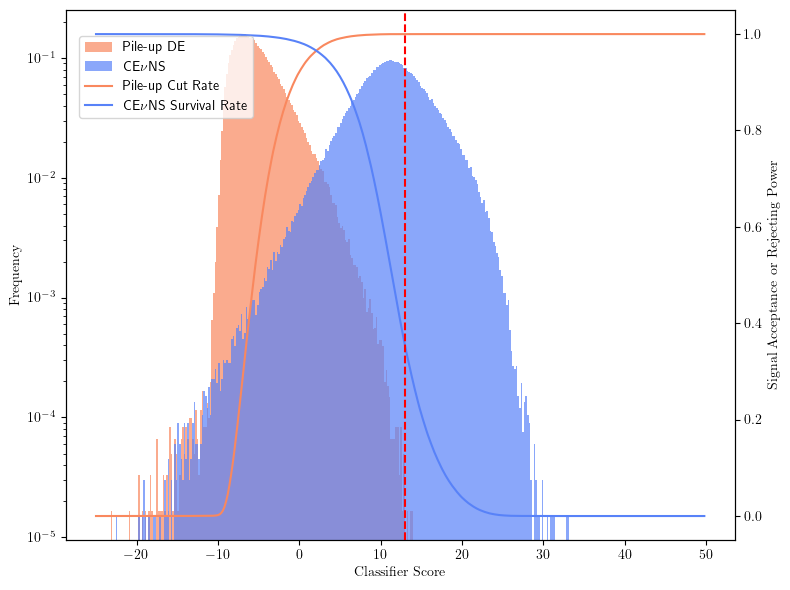

In [224]:
# 导入所需要的库
import matplotlib.pyplot as plt
import numpy as np

cevns_color = '#5882F8'
DE_color = '#F9885E'

# 创建一个新的图形并设置大小
fig, ax1 = plt.subplots(figsize=(8,6))
plt.rcParams['text.usetex'] = True

# 开始处理第一个图，使用左侧y轴

color = 'tab:blue'
bins = np.arange(-25, 50, 0.2)

ax1.hist(score_DE, bins=bins, log=True, label='Pile-up DE', alpha=0.7, color=DE_color,density = True)  # 添加 alpha 参数
ax1.hist(score_CEvNS, bins=bins, log=True, label=r"CE$\nu$NS", alpha=0.7, color=cevns_color,density = True)  # 添加 alpha 参数
ax1.set_ylabel(r'$\mathrm{Frequency}$')  # 右侧y轴标签
ax1.set_xlabel(r'$\mathrm{Classifier\ Score}$')  # x轴标签
ax1.tick_params(axis='y')  # y轴标签颜色

# 第二个图，使用右侧y轴
ax2 = ax1.twinx() 
ax2.set_ylabel(r'$\mathrm{Signal\ Acceptance\ or\ Rejecting\ Power}$')  # 左侧y轴标签
ax2.plot(thresholds, left_DE_ratios, label='Pile-up Cut Rate', color= DE_color)  # 绘制左侧 DE 的比例曲线
ax2.plot(thresholds, right_cevns_ratios, label=r'CE$\nu$NS Survival Rate', color=cevns_color)  # 绘制右侧 CEVNS 的比例曲线
# ax2.grid(True)
ax2.tick_params(axis='y')  # y轴标签颜色


# 获得所有子图的 legend labels 和 handles
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# 创建一个全局的legend
fig.legend(lines + lines2, labels + labels2, loc=(0.10,0.80))
# fig.legend(lines, labels, loc=(0.17,0.8))

# fig.tight_layout(pad = 5)  # 使布局紧密
# plt.title('Pattern Classifier', fontsize=16)  # 图表标题

plt.axvline(x=thresholds[index], color='red', linestyle='dashed')
plt.tight_layout() 
# plt.savefig("classifier_score.png")
plt.show()  # 显示绘图


In [225]:
pipe.time_range_s

10294.5

In [226]:
sel_thres = thresholds[index]
sel_thres

12.999999999999865

In [234]:
def plot_area_spectrum(area, total_time, LXe_mass, bins, **kwargs):
    """
    Plot area spectrum. Frequency (y axis) is converted to [Hz/10^3 PE].
    """
    
    # get area frequency and convert to Hz/10^3 PE
    count, bins = np.histogram(area, bins=bins)
    bin_width = np.diff(bins)
    freq = 86400 * count / (bin_width) / total_time / LXe_mass
    err = np.sqrt(count)
    # create canvas
    ax = plt.gca() # get current axes
    
    # plot spectrum
    ax.stairs(freq, edges=bins, **kwargs)
    ax.set_xlabel('area [PE]')
    ax.set_ylabel('Freq [Counts/(Day*kg*PE)]')
    
    return ax, count, bins

In [228]:
DE_cut = score_DE > sel_thres

Text(0.5, 1.0, 'Pile-up DE area spectrum')

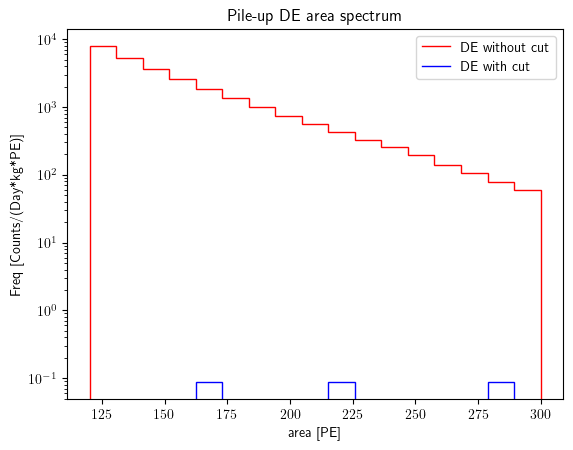

In [235]:
bins = np.linspace(120,300,18)
total_time = pipe.time_range_s
plot_area_spectrum(DE_area[DE_ROI_mask], total_time, LXe_mass=8.98, bins=bins, label='DE without cut', color='red')
plot_area_spectrum(DE_area[DE_ROI_mask][DE_cut], total_time, LXe_mass=8.98, bins=bins, label='DE with cut', color='blue')
plt.yscale('log')
plt.legend()
plt.title('Pile-up DE area spectrum')

In [236]:
len(DE_area[DE_ROI_mask][DE_cut])

3

In [237]:
(len(DE_area[DE_ROI_mask][DE_cut])/total_time)*3600*24*365

9190.15008013988

In [238]:
len(DE_area[DE_ROI_mask])/total_time

29.38005731215698

In [239]:
len(DE_area)/total_time

259.64204186701636